In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [3]:
train = pd.read_csv(r'C:\Users\divin\OneDrive\Desktop\Data_Science\project\UK_House_Price_Prediction_Model\train_basic.csv')

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Target distribution

House prices often have a long right tail: a small number of expensive houses can pull the distribution upward.

For modelling, we often use `log1p(SalePrice)` because it reduces skewness.

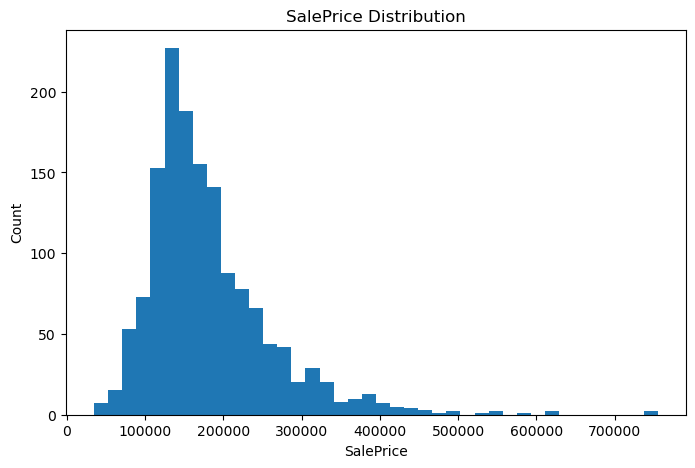

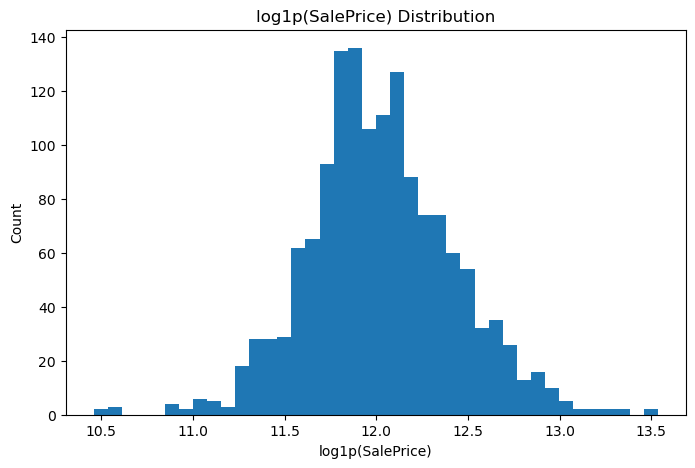

SalePrice skew: 1.8828757597682129
log1p(SalePrice) skew: 0.12134661989685333


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(train['SalePrice'], bins=40)
ax.set_title('SalePrice Distribution')
ax.set_xlabel('SalePrice')
ax.set_ylabel('Count')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log1p(train['SalePrice']), bins=40)
ax.set_title('log1p(SalePrice) Distribution')
ax.set_xlabel('log1p(SalePrice)')
ax.set_ylabel('Count')
plt.show()

print('SalePrice skew:', train['SalePrice'].skew())
print('log1p(SalePrice) skew:', np.log1p(train['SalePrice']).skew())

## 2. Numeric correlation with SalePrice

Correlation measures the strength of a linear relationship.

Important note:

- High positive correlation means the feature tends to increase with price.
- Low correlation does not always mean useless. Some categorical features and non-linear relationships may still be important.

In [7]:
numeric_cols = train.select_dtypes(include=np.number).columns
corr = train[numeric_cols].corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


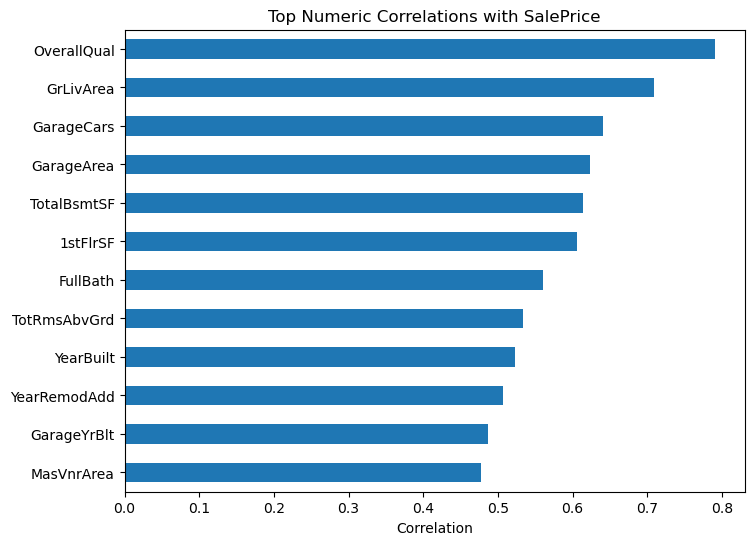

In [8]:
top_corr = corr.drop('SalePrice').head(12)
plt.figure(figsize=(8, 6))
top_corr.sort_values().plot(kind='barh')
plt.title('Top Numeric Correlations with SalePrice')
plt.xlabel('Correlation')
plt.show()

#### Relationship plots for important numeric features

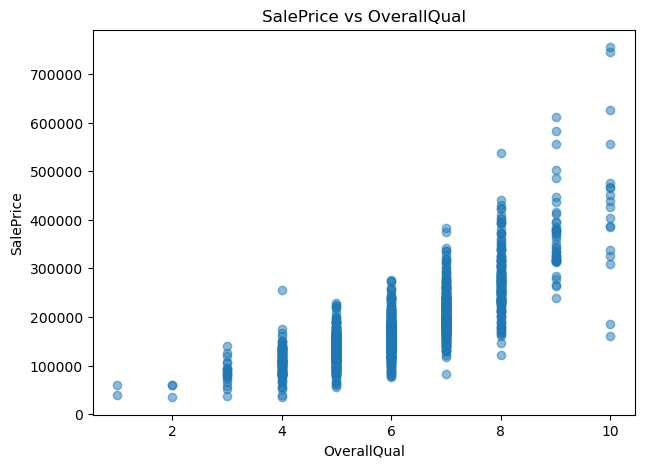

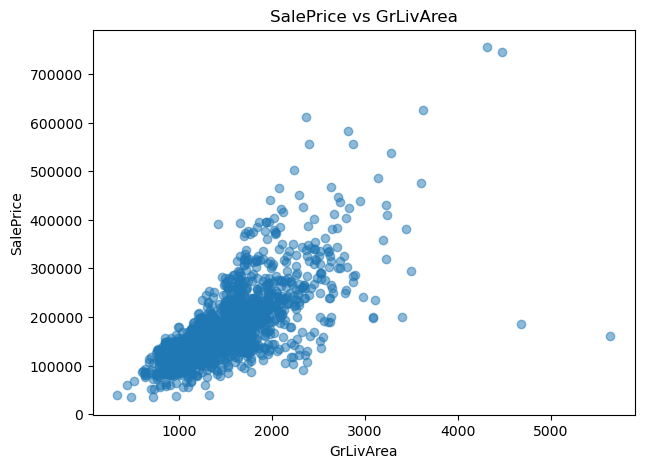

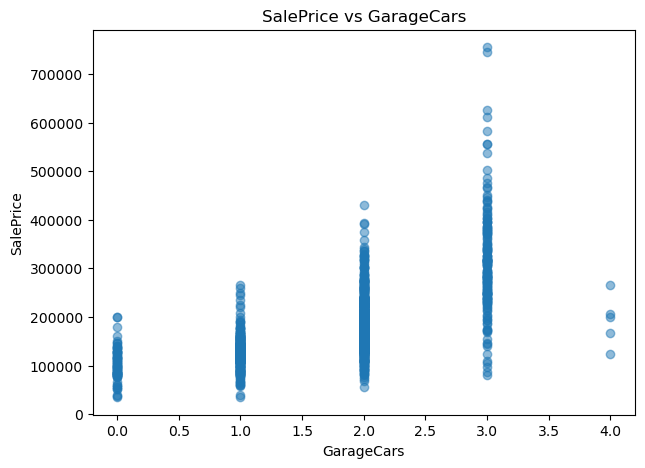

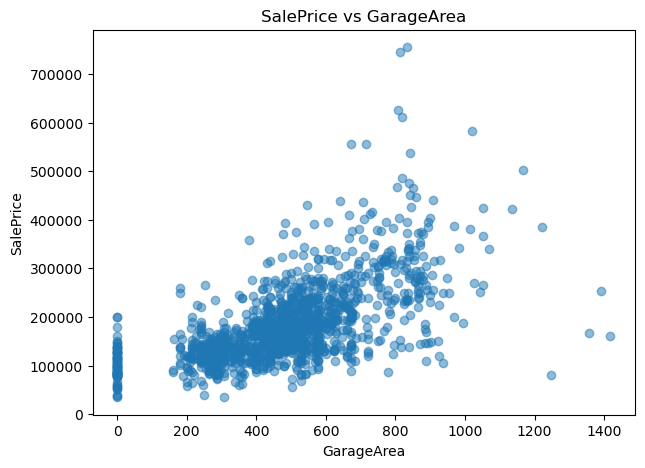

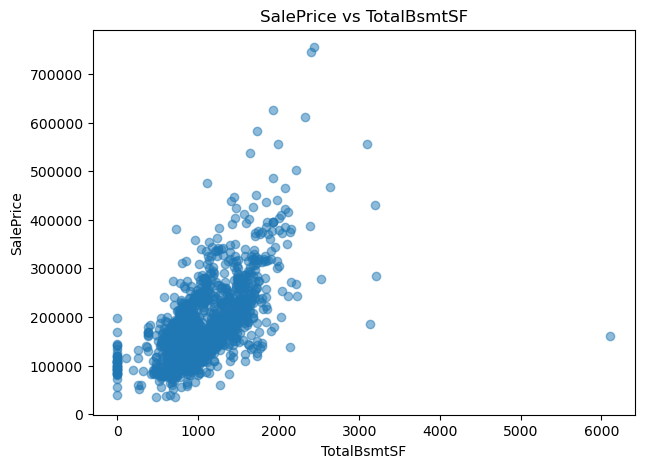

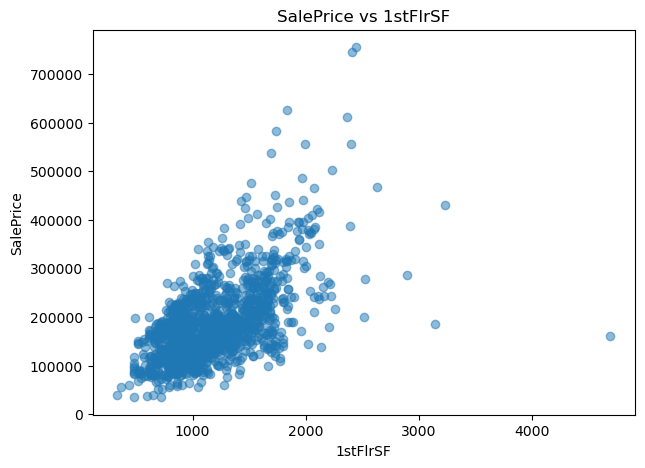

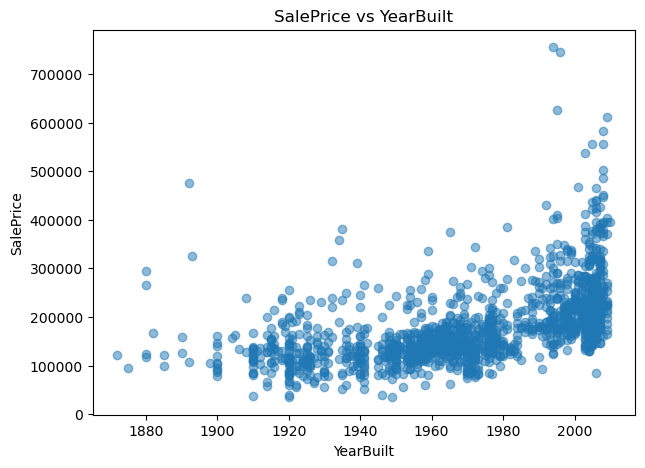

In [9]:
important_numeric = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt']

for col in important_numeric:
    plt.figure(figsize=(7, 5))
    plt.scatter(train[col], train['SalePrice'], alpha=0.5)
    plt.title(f'SalePrice vs {col}')
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.show()

#### Outlier investigation

From the `GrLivArea` plot, we usually see a few very large houses that sold for unexpectedly low prices.

Outliers can affect linear models strongly. We will not automatically remove them yet, but we identify them for discussion.

In [10]:
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print(outliers[['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']])

        Id  GrLivArea  SalePrice  OverallQual Neighborhood
523    524       4676     184750           10      Edwards
1298  1299       5642     160000           10      Edwards


#### Categorical analysis: Neighborhood

Location is usually very important for housing prices.

Here we compare median `SalePrice` by `Neighborhood`. Median is useful because it is less affected by outliers than mean.

,count,median,mean
Neighborhood,,,
NridgHt,77,315000.0,316270.623377
NoRidge,41,301500.0,335295.317073
StoneBr,25,278000.0,310499.000000
Timber,38,228475.0,242247.447368
Somerst,86,225500.0,225379.837209
Veenker,11,218000.0,238772.727273
Crawfor,51,200624.0,210624.725490
ClearCr,28,200250.0,212565.428571
CollgCr,150,197200.0,197965.773333


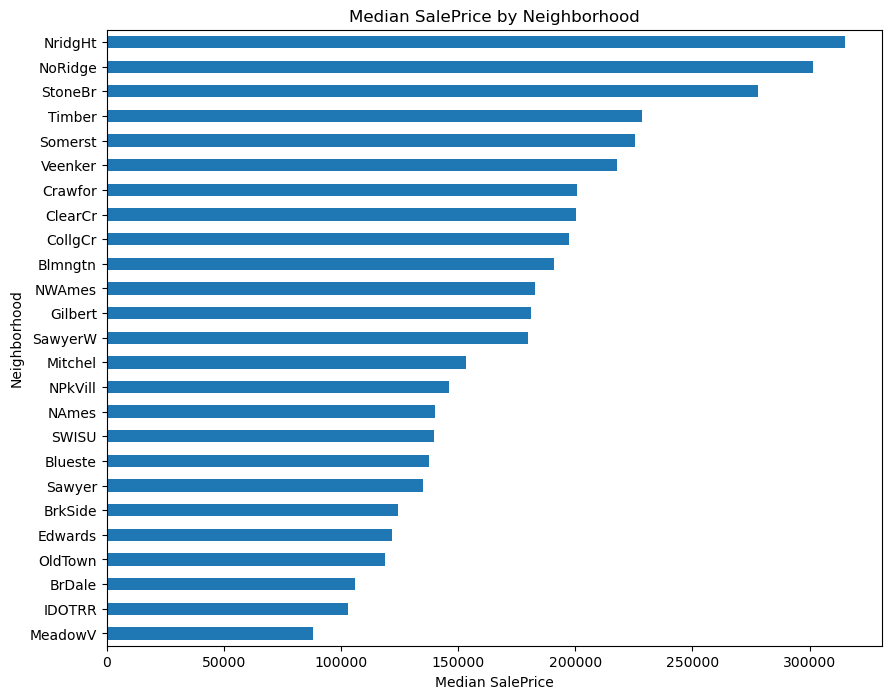

In [11]:
neighborhood_price = train.groupby('Neighborhood')['SalePrice'].agg(['count', 'median', 'mean']).sort_values('median', ascending=False)
display(neighborhood_price)

plt.figure(figsize=(10, 8))
neighborhood_price['median'].sort_values().plot(kind='barh')
plt.title('Median SalePrice by Neighborhood')
plt.xlabel('Median SalePrice')
plt.show()

#### Quality features vs price

Quality features such as `OverallQual`, `KitchenQual`, and `ExterQual` often have strong price relationships.

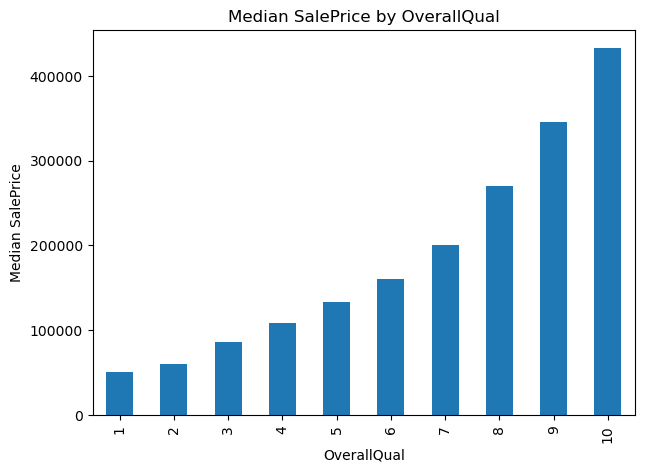

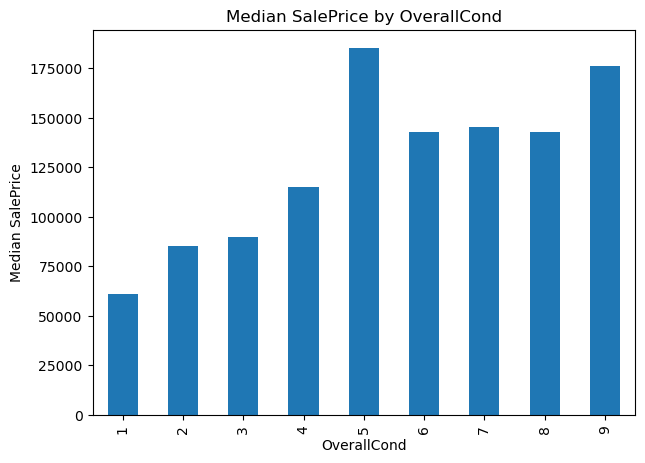

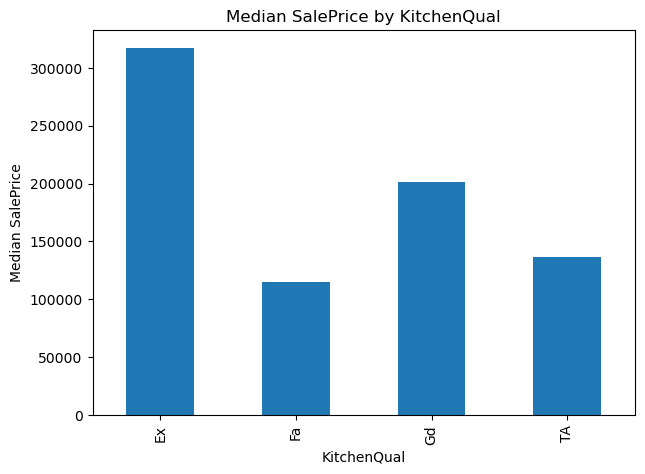

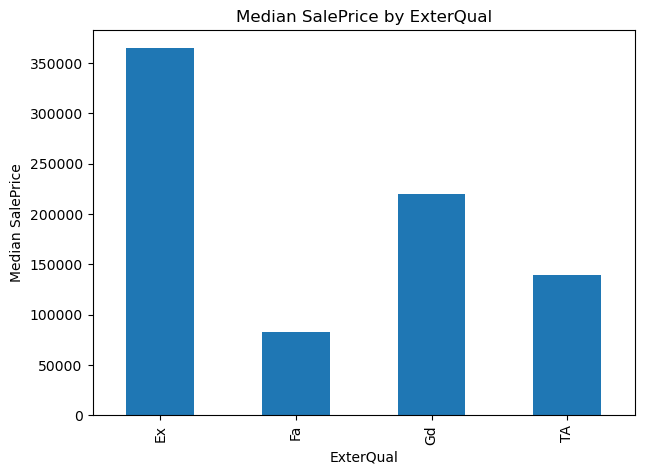

In [13]:
quality_cols = ['OverallQual', 'OverallCond', 'KitchenQual', 'ExterQual']

for col in quality_cols:
    if col in train.columns:
        grouped = train.groupby(col)['SalePrice'].median().sort_index()
        plt.figure(figsize=(7, 5))
        grouped.plot(kind='bar')
        plt.title(f'Median SalePrice by {col}')
        plt.xlabel(col)
        plt.ylabel('Median SalePrice')
        plt.show()

In [14]:

missing = train.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_pct})
display(missing_table[missing_table['missing_count'] > 0].head(25))

,missing_count,missing_percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageCond,81,5.55
GarageType,81,5.55


#### EDA findings for next step


1. `SalePrice` is right-skewed, so `log1p(SalePrice)` is useful for modelling.
2. `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, and `TotalBsmtSF` are strongly related to price.
3. `Neighborhood` has a clear relationship with price.
4. Some outliers exist, especially very large houses with lower-than-expected prices.
5. Feature engineering should create total-size, age, bathroom, porch, and binary availability features.

